In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np
import os
from sklearn.cluster import KMeans
from tqdm import tqdm
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
import matplotlib.ticker as mticker
from collections import Counter
from scipy.stats import pearsonr
import seaborn as sns

from scipy import sparse

In [2]:
def bootstrapping(df_to_bootstrap, grouping_column, groups, y_column, sample_size=100, num_samples=1000):

    prob_derivatives_per_active_eng = {i: df_to_bootstrap[df_to_bootstrap[grouping_column] == i] for i in groups}
    prob_derivatives_sampled = {i: [] for i in groups}

    for group in groups:
        for sample_index in range(num_samples):
            df = prob_derivatives_per_active_eng[group]
            df = df.sample(sample_size, replace=True)
            derivative_mean = df[y_column].mean()
            if derivative_mean > 30:
                print(derivative_mean)
            prob_derivatives_sampled[group] += [derivative_mean]

    prob_derivatives_sampled_mean = {i: np.mean(prob_derivatives_sampled[i]) for i in groups}
    prob_derivatives_sampled_std = {i: np.std(prob_derivatives_sampled[i]) for i in groups}
    return prob_derivatives_sampled_mean, prob_derivatives_sampled_std


def plot_bootstrapping(prob_derivatives_sampled_mean, prob_derivatives_sampled_std, plot_title, xlabel, ylabel, groups):

    plt.errorbar(
        x=groups,
        y=list(prob_derivatives_sampled_mean.values()),
        yerr=list(prob_derivatives_sampled_std.values()),
        ls='none'
    )
    plt.scatter(
        x=groups,
        y=list(prob_derivatives_sampled_mean.values()),
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

    plt.savefig(plot_title, dpi=300)

In [3]:
# data_folder = f'{data_folder}/umap25'
data_folder = f'.'

# svd_embeddings = pd.read_csv(f'{data_folder}/light_pandas_core_track_svd_2024_11_04.csv', low_memory=False)
svd_embeddings = pd.read_csv(f'{data_folder}/svd_embeddings.csv', low_memory=False)

In [4]:
# To reduce memory consumption, convert the anonymized / hashed user and track IDs to integers.

In [5]:
anonymized = svd_embeddings.song_id.unique()
anonymized_to_integers = {anonymized_id: integer for integer, anonymized_id in enumerate(anonymized)}

In [6]:
# svd_embeddings = svd_embeddings.drop(columns=["Unnamed: 0"])
svd_embeddings.song_id = svd_embeddings.song_id.map(anonymized_to_integers)

In [7]:
distances_index_song_id = svd_embeddings.rename_axis('distances_index').reset_index()[['distances_index', 'song_id']]

In [8]:
# The SVD embeddings vectors in R^{128}.
len(svd_embeddings.list_embeddings.values[0].split(', '))

128

In [9]:
# Convert the SVD from strings to lists
svd_embeddings['list_embeddings'] = svd_embeddings['list_embeddings'].apply(ast.literal_eval)

In [10]:
svd_embeddings = svd_embeddings.set_index('song_id')

In [11]:
%%time 
svd_embeddings_series = svd_embeddings.list_embeddings.apply(pd.Series)

CPU times: user 3.5 s, sys: 168 ms, total: 3.67 s
Wall time: 3.54 s


In [12]:
# Matrix of SVD embeddings. Row indices correspond to track indices
svd_embeddings_matrix = svd_embeddings_series.values.astype(np.float32)

In [13]:
svd_embeddings_matrix_path = os.path.join(data_folder, 'svd_embeddings_matrix_2024_11_04.npy')
np.save(svd_embeddings_matrix_path, svd_embeddings_matrix)
# svd_embeddings_matrix = np.load(svd_embeddings_matrix_path)

In [14]:
svd_embeddings_matrix.shape

(76035, 128)

In [15]:
# n_clusters were selected above the elbow, and to have a low Jaccard among editorial playlists
# Now we cluster the SVD embeddings to define the track clusters
n_clusters = 128
clusterer = KMeans(n_clusters=n_clusters, random_state=10)
cluster_labels = clusterer.fit_predict(svd_embeddings_matrix)

## Cluster distances

In [16]:
# Compute the distance of each track from each cluster centroid
all_tracks_from_all_cluster_distances = clusterer.transform(svd_embeddings_matrix)

In [17]:
# Get the distance of each track from the cluster centroid it belongs to
cluster_distances = np.min(all_tracks_from_all_cluster_distances, axis=1)

In [18]:
svd_embeddings["labels"] = cluster_labels
svd_embeddings["distances"] = cluster_distances

## Cluster centroid distances, needed for Rao-Stirling diversity

In [19]:
# Get the distance of each cluster centroid from any other cluster centroid
cluster_centroids = clusterer.cluster_centers_
cluster_centroid_distances = clusterer.transform(cluster_centroids)

# Sanity check:
# shape is num_clusters x num_clusters
cluster_centroid_distances.shape

(128, 128)

In [20]:
# Sanity check:
# diagonal is 0 as it should be: these are distances from a centroid to itself
cluster_centroid_distances[:3, :3]

array([[0.       , 1.2821053, 1.2501978],
       [1.2821053, 0.       , 1.2806451],
       [1.2501978, 1.2806451, 0.       ]], dtype=float32)

# Popularity in Clusters
The popularity is computed over the same set of listening events used for carrying out our analysis on genre preferences

In [21]:
# long_term_les = pd.read_csv(f'{data_folder}/pandas_long_term_les_2024_11_04.csv')
long_term_les = pd.read_csv(f'{data_folder}/long_term_les.csv')
# long_term_les = long_term_les.drop(columns=["Unnamed: 0"])

In [22]:
long_term_les.song_id = long_term_les.song_id.map(anonymized_to_integers)

In [23]:
# Map the hashed user_id to integers
anonymized_users = long_term_les.user_id.unique()
anonymized_user_to_integers = {anonymized_id: integer for integer, anonymized_id in enumerate(anonymized_users)}

In [24]:
long_term_les.user_id = long_term_les.user_id.map(anonymized_user_to_integers)

In [25]:
# first_timestamp: timestamp of first interaction with the track
# last_timestamp: timestamp of last interaction with the track
# total_frequency: total number of interactions of that user with that track
long_term_les.head(1)


,user_id,song_id,first_timestamp,last_timestamp,total_frequency
0,0,11,1651160883,1684223794,11


In [26]:
# Define popularity as the total number of listens
item_popularities = long_term_les[['song_id', 'total_frequency']].groupby('song_id').sum().reset_index()

In [27]:
'number of interactions {}, number of users {}, number of items {}, unique user--item pairs {}'.format(long_term_les.total_frequency.sum(), long_term_les.user_id.nunique(), long_term_les.song_id.nunique(), len(long_term_les.total_frequency))

'number of interactions 28678935, number of users 4070, number of items 72555, unique user--item pairs 3435564'

In [28]:
# Popularity defined as the logarithm of the total number of listenings of a track
svd_embeddings = svd_embeddings.merge(item_popularities[["song_id", "total_frequency"]], left_on="song_id", right_on="song_id")
svd_embeddings['track_popularity'] = svd_embeddings['total_frequency'].apply(lambda x: np.log(x))

In [29]:
# Get the mean frequency and mean popularity of tracks for each cluster
label_to_mean_frequency = svd_embeddings[['labels', 'total_frequency', 'track_popularity']].groupby('labels').mean().to_dict()['total_frequency']
label_to_mean_popularity = svd_embeddings[['labels', 'total_frequency', 'track_popularity']].groupby('labels').mean().to_dict()['track_popularity']

In [30]:
label_to_mean_popularity = dict(sorted(label_to_mean_popularity.items(), key=lambda item: item[1]))

# Per-user Analyses

In [31]:
# long_term_les = long_term_les.drop(columns=["last_timestamp", "total_frequency"])

In [32]:
# combine the listening events of each user with the
# - cluster label
# - distance from cluster centroid
# long_term_les_labels = long_term_les.drop(columns=["last_timestamp", "total_frequency"]).merge(svd_embeddings.reset_index()[["song_id", "labels", "distances"]], left_on="song_id", right_on="song_id")

In [33]:
# Sort the listening events of each user according to the time the track was listened to for the first time
# long_term_les_labels = long_term_les_labels.sort_values(by=["user_id", "first_timestamp"])

In [34]:
def one_user_get_dict(one_user):
    """
    Function that computes the user's preference distribution over clusters in a rolling fashion.
    For each newly listened track, it computes the fraction of newly listened tracks prior and including the current
    and for each cluster. The returned dataframe has three additional columns:
     - dictionary: the dictionary of frequencies over clusters up to now
     - current_prob: the frequency of the cluster currently listened to
     - current_distance: the distance from the cluster centroid of the currently listened track
     - current_probs_x_distances: product of the two above
    :param one_user: dataframe storing the listening events of each user
    :return:
    """
    dictionaries = []
    current_probs = [] # p(c | u)
    current_distances = [] # p(i | c)
    current_probs_x_distances = [] # NOT p(i | u) because not summed over clusters
    for header_max in range(len(one_user)):
        past_tracks = one_user.iloc[:header_max, :]
        dictionary = past_tracks.labels.value_counts().to_dict()
        dictionaries.append(dictionary)
        total = sum(dictionary.values())
        # print(one_user.iloc[header_max].distances)
        # return 0
        current_distance = one_user.iloc[header_max].distances
        
        try:
            current_prob = dictionary.get(one_user.iloc[header_max].labels, 0) / total
        except ZeroDivisionError:
            current_prob = 0.
        current_probs.append(current_prob)
        current_distances.append(current_distance)
        prob_x_distance = current_prob * current_distance
        current_probs_x_distances.append(prob_x_distance)
    one_user["dictionary"] = dictionaries
    one_user["current_prob"] = current_probs
    one_user["current_distance"] = current_distances
    one_user["current_probs_x_distances"] = current_probs_x_distances
    return one_user

def apply_one_user_to_full_les(full_les):
    user_dfs = []
    total_users = full_les.user_id.nunique()
    for user_id in tqdm(full_les.user_id.unique(), total=total_users):
        one_user = full_les[full_les["user_id"] == user_id].copy()
        one_user = one_user_get_dict(one_user)
        user_dfs.append(one_user)
    full_les = pd.concat(user_dfs, ignore_index=True)
    return full_les

In [35]:
# long_term_les_dictionaries = apply_one_user_to_full_les(long_term_les_labels)

In [36]:
long_term_les_dictionaries_path = os.path.join(data_folder, 'svd_probs_evolution_2024_11_04_new_distance.npy')
# long_term_les_dictionaries.to_csv(long_term_les_dictionaries_path, index=False)
long_term_les_dictionaries = pd.read_csv(long_term_les_dictionaries_path)

In [37]:
# Shift the user's listening events from absolute timestamps to timestamps from their overall first interaction
users_first_timestamps = long_term_les_dictionaries[["user_id", "first_timestamp"]].groupby("user_id").min().to_dict()
long_term_les_dictionaries['t_0'] = long_term_les_dictionaries.user_id.map(users_first_timestamps['first_timestamp'])

In [38]:
# Delta_t from the user's overall first interaction
long_term_les_dictionaries['delta_t'] = long_term_les_dictionaries['first_timestamp'] - long_term_les_dictionaries['t_0']

In [39]:
# Rank of tracks as they are listened by a user
long_term_les_dictionaries['num_interactions'] = long_term_les_dictionaries.groupby("user_id")["delta_t"].rank(method="dense", ascending=True)

# Shannon Entropy of last listen over clusters
We measure the user's diversity in tastes as the Shannon entropy of discoveries till now,

In [40]:
long_term_les_dictionaries['dictionary'] = long_term_les_dictionaries['dictionary'].apply(ast.literal_eval)

In [41]:
# long_term_les_dictionaries['cluster_frequencies'] = np.nan
# for index, row in tqdm(long_term_les_dictionaries.iterrows()):
# 
#     total = sum(row.dictionary.values())
#     cluster_frequency = {k: v / total for k, v in row.dictionary.items()}
#     long_term_les_dictionaries.at[index, 'cluster_frequencies'] = cluster_frequency
#     break

In [42]:
def normalize_dictionary(dictionary):
    """
    Convert a dictionary of frequencies to a dictionary of fractions
    :param dictionary:
    :return:
    """
    total = sum(dictionary.values())    
    normalized_dictionary = {k: v / total for k, v in dictionary.items()}
    return normalized_dictionary

In [48]:
def rao_stirling_diversity(cluster_frequencies, n_clusters=n_clusters, centroid_distances=cluster_centroid_distances):
    """
    Computes the Rao-Stirling diversity as measure of users' streaming profile diversity over clusters.
    Follows the approach of Way et al.
    https://ojs.aaai.org/index.php/ICWSM/article/view/3250/3118

    The diversity is defined as

    div_RS = Σ_{ij} p_i p_j d(i,j)

    where p_i represents the fraction of listens in cluster i, and d(i,j) represents the distance between cluster i and cluster j.

    Since the clustering is done with L2 norm,

    :param cluster_frequencies: dictionary of frequency of past consumptions over clusters
    :param centroid_distances: numpy matrix of cluster centroid distances
    :return rao_stirling_diversity: float value of current rao_stirling_diversity
    """

    values = list(cluster_frequencies.values())
    row_indices = list(cluster_frequencies.keys())
    column_indices = [0] * len(row_indices)

    pis = sparse.csc_array((values, (row_indices, column_indices)), shape=(n_clusters, 1)).toarray().flatten()
    pis_pjs = np.outer(pis, pis, out=None)

    pis_pjs_d_ij = np.multiply(pis_pjs, centroid_distances)

    div_RS = pis_pjs_d_ij.sum()

    return div_RS


In [44]:
long_term_les_dictionaries['cluster_frequencies'] = long_term_les_dictionaries['dictionary'].apply(normalize_dictionary)

In [45]:
user_entropies = long_term_les_dictionaries.merge(long_term_les_dictionaries.groupby(['user_id'])['delta_t'].max().reset_index(), left_on=['user_id', 'delta_t'], right_on=['user_id', 'delta_t'])[['user_id', 'cluster_frequencies']]

In [46]:
# Compute Shannon entropy over clusters in a rolling fashion
user_entropies['entropy_over_clusters'] = user_entropies['cluster_frequencies'].apply(lambda x: -np.sum([pi * np.log(pi) for pi in x.values()]))

# Rao Stirling

In [49]:
user_entropies['rao_stirling_over_clusters'] = user_entropies['cluster_frequencies'].apply(rao_stirling_diversity)

In [50]:
user_entropies[['rao_stirling_over_clusters', 'entropy_over_clusters']].corr()

,rao_stirling_over_clusters,entropy_over_clusters
rao_stirling_over_clusters,1.000000,0.873171
entropy_over_clusters,0.873171,1.000000


# Back to previous notebook:

In [51]:
svd_embeddings = svd_embeddings.rename(columns={'total_frequency': 'popularity_as_frequency'})

In [52]:
long_term_les_labels = long_term_les.drop(columns=["last_timestamp"]).merge(svd_embeddings[['song_id', 'popularity_as_frequency', 'track_popularity', 'labels', 'distances']], on="song_id", how="left")

In [53]:
# In order to convert the track popularity and track distance in relation to the corresponding cluster, also get the
# average popularity and average distance of tracks in each cluster.
cluster_mean_frequency = pd.Series(label_to_mean_frequency).reset_index()
cluster_mean_frequency.columns = ['labels', 'mean_cluster_frequency']

In [54]:
cluster_mean_popularity = pd.Series(label_to_mean_popularity).reset_index()
cluster_mean_popularity.columns = ['labels', 'mean_cluster_popularity']

In [55]:
cluster_mean_distances = svd_embeddings[['labels', 'distances']].groupby('labels').mean().reset_index().rename(columns={'distances': 'mean_cluster_distance'})

In [56]:
cluster_mean_track_listens_by_user = long_term_les_labels.groupby('labels')['total_frequency'].mean().reset_index().rename(columns={'total_frequency': 'mean_cluster_total_frequency'})

In [57]:
# Again, getting the overall first timestamp of interaction for each user (what above was t_0)
users_first_interaction_ever = long_term_les_labels[['user_id', 'first_timestamp']].groupby('user_id').min()
users_first_interaction_ever.columns = ['first_interaction_ever']

users_clusters_in_xxx_six_months = long_term_les_labels.merge(users_first_interaction_ever, on='user_id')

# Isolate the first six months of each user to define the long-term preferences
users_clusters_in_first_six_months = users_clusters_in_xxx_six_months[(users_clusters_in_xxx_six_months.first_timestamp - users_clusters_in_xxx_six_months.first_interaction_ever) < (30 * 24 * 60 * 60 * 6)]
users_clusters_in_last_six_months = users_clusters_in_xxx_six_months[(users_clusters_in_xxx_six_months.first_timestamp - users_clusters_in_xxx_six_months.first_interaction_ever) >= (30 * 24 * 60 * 60 * 6)]

In [58]:
# For each user, get the final number of discoveries in a cluster after six months of interactions
users_clusters_in_first_six_months = users_clusters_in_first_six_months[['user_id', 'labels']].groupby(['user_id','labels']).size().reset_index().rename(columns={0:'cluster_listens_in_first_six_months'})

In [59]:
# Get a dictionary of the labels that each user already listened in the first six months
dict_users_clusters_in_first_six_months = {
    user_id: set(
        users_clusters_in_first_six_months[users_clusters_in_first_six_months.user_id == user_id]['labels'].unique()
    ) for user_id in users_clusters_in_first_six_months.user_id.unique()
}

In [60]:
# For the remaining six months, only restrict to clusters that were not listened to before
user_dfs = []
for user_id in tqdm(users_clusters_in_last_six_months.user_id.unique()):
    user_df = users_clusters_in_last_six_months[users_clusters_in_last_six_months.user_id == user_id]
    user_df = user_df[~user_df.labels.isin(dict_users_clusters_in_first_six_months[user_id])]
    user_dfs += [user_df]

100%|██████████| 3885/3885 [00:02<00:00, 1729.03it/s]


In [61]:
users_clusters_in_last_six_months = pd.concat(user_dfs, ignore_index=True)

In [62]:
# For each newly listened track, get the delta_t of the track listen from the discovery of the corresponding cluster
users_clusters_in_last_six_months = users_clusters_in_last_six_months[['user_id', 'labels', 'first_timestamp']].groupby(['user_id','labels']).min().rename(
        columns={'first_timestamp': 'first_cluster_timestamp'}).merge(
    users_clusters_in_last_six_months,
    how='right',
    left_on=['user_id', 'labels'],
    right_on=['user_id', 'labels'], 
)

users_clusters_in_last_six_months['delta_t_from_cluster_discovery'] = users_clusters_in_last_six_months['first_timestamp'] - users_clusters_in_last_six_months['first_cluster_timestamp']

In [63]:
# Range of delta_t from cluster discovery, roughly expressed in months
users_clusters_in_last_six_months.delta_t_from_cluster_discovery.min(), users_clusters_in_last_six_months.delta_t_from_cluster_discovery.max() / (30 * 24 * 60 * 60)

(0, 6.135418209876543)

In [64]:
# rank tracks according to the order of listen in cluster discovery
users_clusters_in_last_six_months['track_rank_in_cluster'] = users_clusters_in_last_six_months.groupby([
    'user_id', 'labels'])['delta_t_from_cluster_discovery'].rank(method='dense', ascending=True).astype(int)
# rank tracks according to their popularity or distance within the cluster, but only among the tracks that this specific user listened to
users_clusters_in_last_six_months['popularity_rank_in_cluster'] = users_clusters_in_last_six_months.groupby([
    'user_id', 'labels'])['track_popularity'].rank(method='dense', ascending=True).astype(int)
users_clusters_in_last_six_months['distance_rank_in_cluster'] = users_clusters_in_last_six_months.groupby([
    'user_id', 'labels'])['distances'].rank(method='dense', ascending=True).astype(int)

users_clusters_in_last_six_months = users_clusters_in_last_six_months.merge(cluster_mean_distances, on='labels')
users_clusters_in_last_six_months = users_clusters_in_last_six_months.merge(cluster_mean_frequency, on='labels')
users_clusters_in_last_six_months = users_clusters_in_last_six_months.merge(cluster_mean_popularity, on='labels')
users_clusters_in_last_six_months = users_clusters_in_last_six_months.merge(cluster_mean_track_listens_by_user, on='labels')

In [65]:
# Get the percentage distances compared to the cluster averages, for both distance and popularity
users_clusters_in_last_six_months['distance_minus_mean'] = users_clusters_in_last_six_months['distances'] - users_clusters_in_last_six_months['mean_cluster_distance']
users_clusters_in_last_six_months['percentage_distance'] = users_clusters_in_last_six_months['distance_minus_mean'] / users_clusters_in_last_six_months['mean_cluster_distance']


users_clusters_in_last_six_months['popularity_minus_mean'] = users_clusters_in_last_six_months['track_popularity'] - users_clusters_in_last_six_months['mean_cluster_popularity']
users_clusters_in_last_six_months['percentage_popularity'] = users_clusters_in_last_six_months['popularity_minus_mean'] / users_clusters_in_last_six_months['mean_cluster_popularity']

users_clusters_in_last_six_months['frequency_minus_mean'] = users_clusters_in_last_six_months['popularity_as_frequency'] - users_clusters_in_last_six_months['mean_cluster_frequency']
users_clusters_in_last_six_months['percentage_frequency'] = users_clusters_in_last_six_months['frequency_minus_mean'] / users_clusters_in_last_six_months['mean_cluster_frequency']

users_clusters_in_last_six_months['total_frequency_minus_mean'] = users_clusters_in_last_six_months['total_frequency'] - users_clusters_in_last_six_months['mean_cluster_total_frequency']
users_clusters_in_last_six_months['percentage_total_frequency_minus_mean'] = users_clusters_in_last_six_months['total_frequency_minus_mean'] / users_clusters_in_last_six_months['mean_cluster_total_frequency']

In [66]:
def get_mean_correlation(data=users_clusters_in_last_six_months, column1='track_rank_in_cluster', column2='popularity_rank_in_cluster', method='kendall', ):
    corr = data.groupby(['user_id', 'labels'])[[column1, column2]].corr(method=method).dropna()
    return corr[column1].values[1::2].mean()

# Analysis for one week from the cluster discovery
For each newly discovered cluster, we look at the tracks that were further discovered (listened to for the first time) to in the subsequent week,


In [67]:
# first_timestamp: first timestamp of this track
# first_cluster_timestamp: first timestamp of the cluster of the current track
users_one_week = users_clusters_in_last_six_months[users_clusters_in_last_six_months.first_timestamp - users_clusters_in_last_six_months.first_cluster_timestamp < 7 * 24 * 60 * 60]

In [68]:
# Check for kendall correlation between the order of listen and the rank in terms of popularity
get_mean_correlation(data=users_one_week, column1='track_rank_in_cluster', column2='percentage_popularity', method='kendall')

-0.20506403369414222

In [69]:
# Same but for distance from centroid
get_mean_correlation(data=users_one_week, column1='track_rank_in_cluster', column2='distance_rank_in_cluster', method='kendall')

-0.0057880013616887285

In [70]:
# Same but for popularity defined in terms of total listens
get_mean_correlation(data=users_one_week, column1='track_rank_in_cluster', column2='percentage_total_frequency_minus_mean', method='kendall')

-0.2362912446618952

In [71]:
# Are users who declare a high interest in unfamiliar music exploring music in a different way?
## Do they tend to discover more clusters?
## Do they tend to listen to less stereotypical stuff?
## Do they tend to listen to less popular stuff?

In [72]:
# load the records data
ils_questions = pd.read_csv(f'{data_folder}/users_questions_with_age_nonbinary_gender.csv')
# ils_questions = ils_questions[['uid', 'active_eng_3']]
ils_questions.uid = ils_questions.uid.map(anonymized_user_to_integers)

In [73]:
# ils_questions.head()
users_clusters_in_last_six_months = users_clusters_in_last_six_months.merge(ils_questions, how='inner', left_on='user_id', right_on='uid')

In [74]:
grouped_users_clusters_in_last_six_months = users_clusters_in_last_six_months.merge(user_entropies, how='inner', left_on='user_id', right_on='user_id')

In [75]:
# For each user, get their
#  - popularity in percentage to the average cluster popularity
#  - distance from centroid in percentage to the average distance from centroid
#  - entropy over clusters (computed at the latest time possible)
users_active_eng = grouped_users_clusters_in_last_six_months.groupby('user_id')[['labels', 'track_popularity', 'percentage_popularity', 'percentage_distance', 'active_eng_3', 'entropy_over_clusters', 'rao_stirling_over_clusters']].agg(
    {'labels': lambda x: len(np.unique(x)),
     'track_popularity': np.mean,
     'percentage_popularity': np.mean,
     'percentage_distance': np.mean,
     'active_eng_3': np.mean,
     'entropy_over_clusters': np.mean,
     # add rao-stirling
     'rao_stirling_over_clusters': np.mean,
     }
)

/tmp/ipykernel_2071862/1883253756.py:5: FutureWarning: The provided callable <function mean at 0x73ee240f3ce0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  users_active_eng = grouped_users_clusters_in_last_six_months.groupby('user_id')[['labels', 'track_popularity', 'percentage_popularity', 'percentage_distance', 'active_eng_3', 'entropy_over_clusters', 'rao_stirling_over_clusters']].agg(


In [76]:
users_active_eng['active_eng_3'] = users_active_eng['active_eng_3'].astype(int)

# Statistical significance
Anova

In [120]:
# Spearman as requested by reviewer 4
users_active_eng.corr(method='spearman')

,labels,track_popularity,percentage_popularity,percentage_distance,active_eng_3,entropy_over_clusters,rao_stirling_over_clusters
labels,1.000000,0.023987,-0.002536,-0.058259,0.075393,0.260449,0.223569
track_popularity,0.023987,1.000000,0.911647,-0.113794,-0.074534,-0.202334,-0.160340
percentage_popularity,-0.002536,0.911647,1.000000,-0.159816,-0.080410,-0.116291,-0.092430
percentage_distance,-0.058259,-0.113794,-0.159816,1.000000,0.031544,0.027735,0.000854
active_eng_3,0.075393,-0.074534,-0.080410,0.031544,1.000000,0.206655,0.209086
entropy_over_clusters,0.260449,-0.202334,-0.116291,0.027735,0.206655,1.000000,0.831314
rao_stirling_over_clusters,0.223569,-0.160340,-0.092430,0.000854,0.209086,0.831314,1.000000


In [77]:
# Correlations and their significances
users_active_eng.corr()

,labels,track_popularity,percentage_popularity,percentage_distance,active_eng_3,entropy_over_clusters,rao_stirling_over_clusters
labels,1.000000,0.031010,-0.010125,-0.106171,0.061116,0.230522,0.208129
track_popularity,0.031010,1.000000,0.907566,-0.130996,-0.082827,-0.187451,-0.144869
percentage_popularity,-0.010125,0.907566,1.000000,-0.181408,-0.083045,-0.093978,-0.066975
percentage_distance,-0.106171,-0.130996,-0.181408,1.000000,0.033529,0.004230,-0.023202
active_eng_3,0.061116,-0.082827,-0.083045,0.033529,1.000000,0.206483,0.198388
entropy_over_clusters,0.230522,-0.187451,-0.093978,0.004230,0.206483,1.000000,0.862718
rao_stirling_over_clusters,0.208129,-0.144869,-0.066975,-0.023202,0.198388,0.862718,1.000000


In [78]:
def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 6)
    return pvalues

In [79]:
calculate_pvalues(users_active_eng)

/tmp/ipykernel_2071862/4105536219.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 6)


,labels,track_popularity,percentage_popularity,percentage_distance,active_eng_3,entropy_over_clusters,rao_stirling_over_clusters
active_eng_3,0.000161,0.0,0.0,0.038602,0.0,0.0,0.0
entropy_over_clusters,0.0,0.0,0.0,0.794174,0.0,0.0,0.0
labels,0.0,0.055758,0.532314,0.0,0.000161,0.0,0.0
percentage_distance,0.0,0.0,0.0,0.0,0.038602,0.794174,0.152402
percentage_popularity,0.532314,0.0,0.0,0.0,0.0,0.0,0.000035
rao_stirling_over_clusters,0.0,0.0,0.000035,0.152402,0.0,0.0,0.0
track_popularity,0.055758,0.0,0.0,0.0,0.0,0.0,0.0


# Track-level instead of cluster-level

In [80]:
grouped_users_clusters_in_last_six_months = grouped_users_clusters_in_last_six_months.merge(distances_index_song_id, on='song_id')

In [81]:
all_tracks_from_all_cluster_distances.shape

(76035, 128)

# Evolution of entropy over time

In [82]:
def compute_entropy(x):
    if len(x) > 0: 
        return - np.sum([pi * np.log(pi) for pi in x.values()]) 
    else: 
        return np.nan

In [83]:
long_term_les_dictionaries['current_entropy'] = long_term_les_dictionaries['cluster_frequencies'].apply(lambda x: compute_entropy(x))

In [86]:
long_term_les_dictionaries['current_rao_stirling'] = long_term_les_dictionaries['cluster_frequencies'].apply(rao_stirling_diversity)

In [87]:
long_term_les_dictionaries_first_six = long_term_les_dictionaries[long_term_les_dictionaries['delta_t']  < (30 * 24 * 60 * 60 * 6)]
entropy_end_of_first_six = long_term_les_dictionaries_first_six.loc[long_term_les_dictionaries_first_six.groupby('user_id').delta_t.idxmax()][['user_id', 'current_entropy', 'current_rao_stirling']].merge(ils_questions, how='inner', left_on='user_id', right_on='uid')

In [88]:
entropy_end_of_first_six[['active_eng_3', 'current_entropy', 'current_rao_stirling']].corr()

,active_eng_3,current_entropy,current_rao_stirling
active_eng_3,1.000000,0.192828,0.186525
current_entropy,0.192828,1.000000,0.873731
current_rao_stirling,0.186525,0.873731,1.000000


In [121]:
entropy_end_of_first_six[['active_eng_3', 'current_entropy', 'current_rao_stirling']].corr(method='spearman')

,active_eng_3,current_entropy,current_rao_stirling
active_eng_3,1.000000,0.194096,0.198032
current_entropy,0.194096,1.000000,0.842038
current_rao_stirling,0.198032,0.842038,1.000000


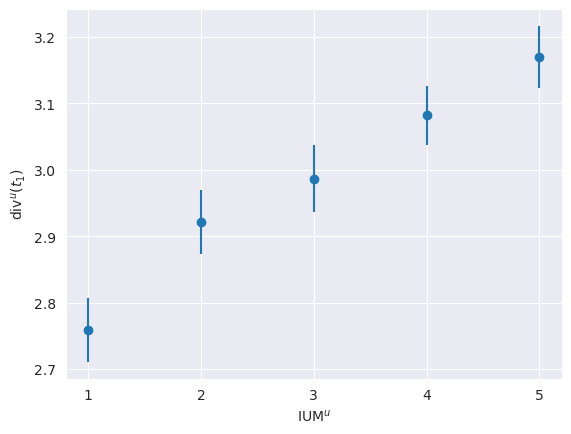

In [89]:
prob_derivatives_sampled_mean, prob_derivatives_sampled_std = bootstrapping(entropy_end_of_first_six, 'active_eng_3', range(1, 6, 1), 'current_entropy', sample_size=100, num_samples=1000)
plot_bootstrapping(prob_derivatives_sampled_mean, prob_derivatives_sampled_std, f'entropy_end_of_first_six_months_n_clusters{n_clusters}.png', 'IUM$^u$', 'div$^u(t_1)$', [1, 2, 3, 4, 5])

In [93]:
entropy_end_of_first_six[['current_entropy', 'current_rao_stirling']].mean()

current_entropy         3.006548
current_rao_stirling    0.940110
dtype: float64

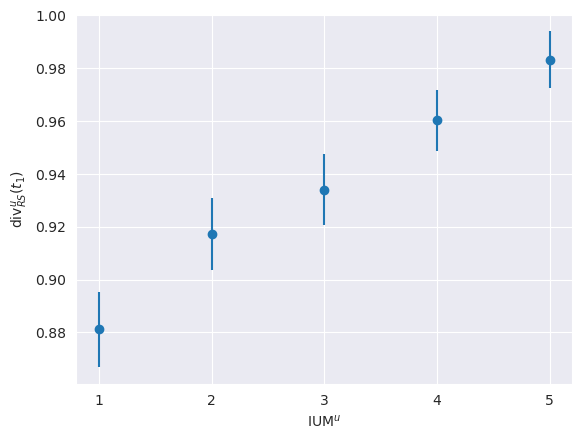

In [94]:
prob_derivatives_sampled_mean, prob_derivatives_sampled_std = bootstrapping(entropy_end_of_first_six, 'active_eng_3', range(1, 6, 1), 'current_rao_stirling', sample_size=100, num_samples=1000)
plot_bootstrapping(prob_derivatives_sampled_mean, prob_derivatives_sampled_std, f'rao_stirling_end_of_first_six_months_n_clusters{n_clusters}.png', 'IUM$^u$', 'div$_{RS}^u(t_1)$', [1, 2, 3, 4, 5])

In [95]:
long_term_les_dictionaries_in_last_six_months = long_term_les_dictionaries[long_term_les_dictionaries.delta_t >= (30 * 24 * 60 * 60 * 6)]

In [96]:
long_term_les_dictionaries_in_last_six_months = long_term_les_dictionaries_in_last_six_months.merge(ils_questions, how='inner', left_on='user_id', right_on='uid')

In [97]:
# Mean entropy in the last six months
mean_entropies = long_term_les_dictionaries_in_last_six_months.groupby('user_id')[['active_eng_3', 'current_entropy']].mean()
mean_entropies.active_eng_3 = mean_entropies.active_eng_3.astype(int)

In [98]:
# std entropy in the last six months
std_entropies = long_term_les_dictionaries_in_last_six_months.groupby('user_id')[['active_eng_3', 'current_entropy']].std()
std_entropies.active_eng_3 = mean_entropies.active_eng_3.astype(int)

# Derivative of the probabilities over time
Does the cluster percentage change with a higher or lower rate for users with a higher or lower interest in unfamiliar music?

In [99]:
# Time difference between two consecutive new tracks
long_term_les_dictionaries_in_last_six_months['delta_delta_t'] = long_term_les_dictionaries_in_last_six_months.groupby('user_id')['delta_t'].diff()

In [100]:
# For each user, compute the difference in the dictionary of clusters
current_user = long_term_les_dictionaries_in_last_six_months.user_id.unique()[0]
past_user = None
previous_dict = Counter({})

differences = []
entropy_differences = []
rao_stirling_differences = []

for row in tqdm(long_term_les_dictionaries_in_last_six_months.iterrows(), total=len(long_term_les_dictionaries_in_last_six_months)):
    row = row[1]
    current_user = row['user_id']

    current_dict = Counter(row['cluster_frequencies'])
    current_entropy = row['current_entropy']
    current_rao_stirling = row['current_rao_stirling']

    if current_user == past_user:
        differences += [current_dict - previous_dict]
        entropy_differences += [current_entropy - previous_entropy]
        rao_stirling_differences += [current_rao_stirling - previous_rao_stirling]
    else:
        # differences += [current_dict]
        differences += [{'dummy': np.nan}]
        entropy_differences += [np.nan]
        rao_stirling_differences += [np.nan]
    previous_dict = current_dict
    previous_entropy = current_entropy
    previous_rao_stirling = current_rao_stirling
    past_user = current_user

100%|██████████| 1058826/1058826 [00:28<00:00, 37784.82it/s]


In [101]:
# Compute the l2 norm of the variation of the probability over clusters (including the not listened ones, which stay at 0)
squared_differences = [np.sqrt(
    (np.fromiter(x.values(), dtype=float) ** 2).sum()
) for x in differences]

In [102]:
long_term_les_dictionaries_in_last_six_months['sqrt_of_squared_differences'] = squared_differences
long_term_les_dictionaries_in_last_six_months['entropy_differences'] = entropy_differences
long_term_les_dictionaries_in_last_six_months['rao_stirling_differences'] = rao_stirling_differences

In [104]:
# Divide the variation over time of the l2 norm over the time interval, to get the (approximation of the) derivative
long_term_les_dictionaries_in_last_six_months['derivative'] = long_term_les_dictionaries_in_last_six_months['sqrt_of_squared_differences'] / long_term_les_dictionaries_in_last_six_months['delta_delta_t']

long_term_les_dictionaries_in_last_six_months['entropy_derivative'] = long_term_les_dictionaries_in_last_six_months['entropy_differences'] / long_term_les_dictionaries_in_last_six_months['delta_delta_t']

long_term_les_dictionaries_in_last_six_months['rao_stirling_derivative'] = long_term_les_dictionaries_in_last_six_months['rao_stirling_differences'] / long_term_les_dictionaries_in_last_six_months['delta_delta_t']

In [105]:
# get the average of the derivative over each user, and represent this as distribution over active engagement values
probability_derivatives = long_term_les_dictionaries_in_last_six_months.groupby('user_id')[['active_eng_3', 'derivative']].mean()
probability_derivatives.active_eng_3 = probability_derivatives.active_eng_3.astype(int)
probability_derivatives = probability_derivatives[~(probability_derivatives.derivative == np.inf)]

In [106]:
# get the average of the derivative over each user, and represent this as distribution over active engagement values
entropy_derivatives = long_term_les_dictionaries_in_last_six_months.groupby('user_id')[['active_eng_3', 'entropy_derivative']].mean()
rao_stirling_derivatives = long_term_les_dictionaries_in_last_six_months.groupby('user_id')[['active_eng_3', 'rao_stirling_derivative']].mean()
entropy_derivatives.active_eng_3 = entropy_derivatives.active_eng_3.astype(int)
entropy_derivatives = entropy_derivatives[~(entropy_derivatives.entropy_derivative == np.inf)]
entropy_derivatives = entropy_derivatives[~(entropy_derivatives.entropy_derivative == -np.inf)]
entropy_derivatives = entropy_derivatives[~(entropy_derivatives.entropy_derivative.isna())]


rao_stirling_derivatives = rao_stirling_derivatives[~(rao_stirling_derivatives.rao_stirling_derivative == np.inf)]
rao_stirling_derivatives = rao_stirling_derivatives[~(rao_stirling_derivatives.rao_stirling_derivative == -np.inf)]
rao_stirling_derivatives = rao_stirling_derivatives[~(rao_stirling_derivatives.rao_stirling_derivative.isna())]

# Bootstrapping

In [107]:
probability_derivatives[['active_eng_3', 'derivative']].corr()

,active_eng_3,derivative
active_eng_3,1.000000,-0.007773
derivative,-0.007773,1.000000


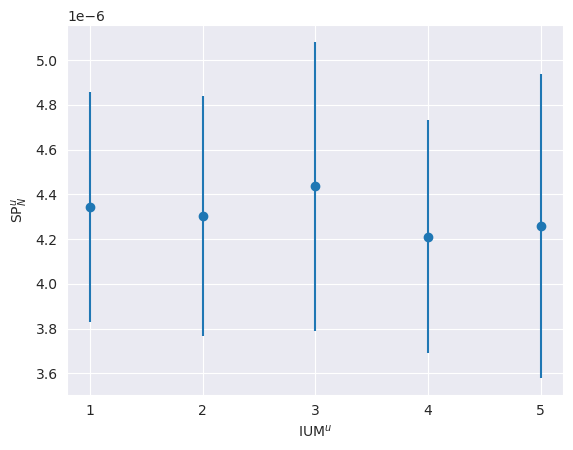

In [108]:
prob_derivatives_sampled_mean, prob_derivatives_sampled_std = bootstrapping(probability_derivatives, 'active_eng_3', range(1, 6, 1), 'derivative', sample_size=100, num_samples=1000)
plot_bootstrapping(prob_derivatives_sampled_mean, prob_derivatives_sampled_std, f'prob_derivative_n_clusters{n_clusters}.png', 'IUM$^u$', 'SP$_N^u$', [1, 2, 3, 4, 5])

In [109]:
users_one_week[['track_rank_in_cluster', 'percentage_popularity', 'percentage_distance']].corr()

,track_rank_in_cluster,percentage_popularity,percentage_distance
track_rank_in_cluster,1.000000,-0.105880,-0.153793
percentage_popularity,-0.105880,1.000000,-0.126925
percentage_distance,-0.153793,-0.126925,1.000000


In [122]:
calculate_pvalues(users_one_week[['track_rank_in_cluster', 'percentage_popularity', 'percentage_distance']])

/tmp/ipykernel_2071862/4105536219.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 6)


,track_rank_in_cluster,percentage_popularity,percentage_distance
percentage_distance,0.0,0.0,0.0
percentage_popularity,0.0,0.0,0.0
track_rank_in_cluster,0.0,0.0,0.0


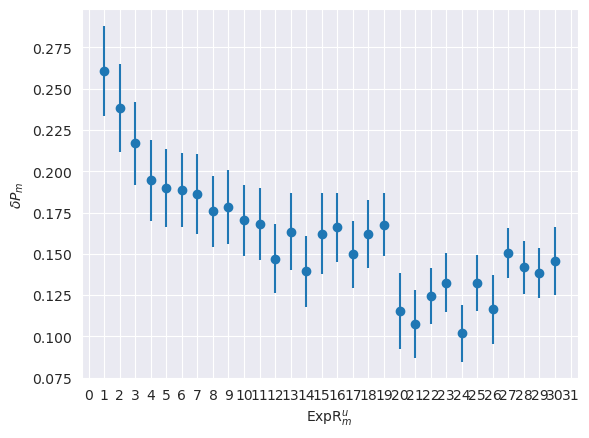

In [111]:
prob_derivatives_sampled_mean, prob_derivatives_sampled_std = bootstrapping(users_one_week, 'track_rank_in_cluster', range(1, 31, 1), 'percentage_popularity', sample_size=100, num_samples=1000)
plot_bootstrapping(prob_derivatives_sampled_mean, prob_derivatives_sampled_std, f'prob_derivative_n_clusters{n_clusters}.png', 'ExpR$^u_m$', '$\delta P_m$', [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

In [112]:
users_active_eng[['labels', 'active_eng_3']].corr()

,labels,active_eng_3
labels,1.000000,0.061116
active_eng_3,0.061116,1.000000


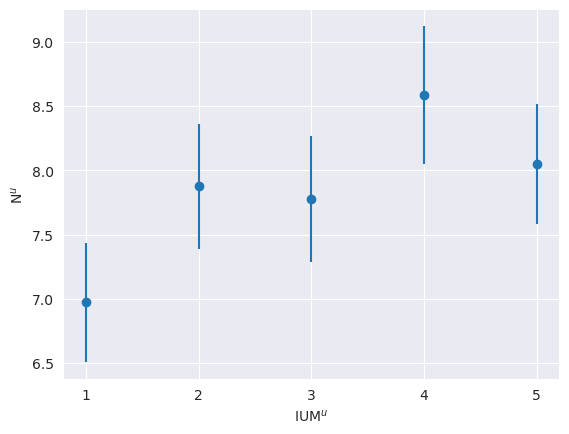

In [113]:
prob_derivatives_sampled_mean, prob_derivatives_sampled_std = bootstrapping(users_active_eng, 'active_eng_3', range(1, 6, 1), 'labels', sample_size=100, num_samples=1000)
plot_bootstrapping(prob_derivatives_sampled_mean, prob_derivatives_sampled_std, f'number_music_communities.png', 'IUM$^u$', 'N$^u$', [1, 2, 3, 4, 5])

In [114]:
entropy_derivatives.corr()

,active_eng_3,entropy_derivative
active_eng_3,1.000000,0.023966
entropy_derivative,0.023966,1.000000


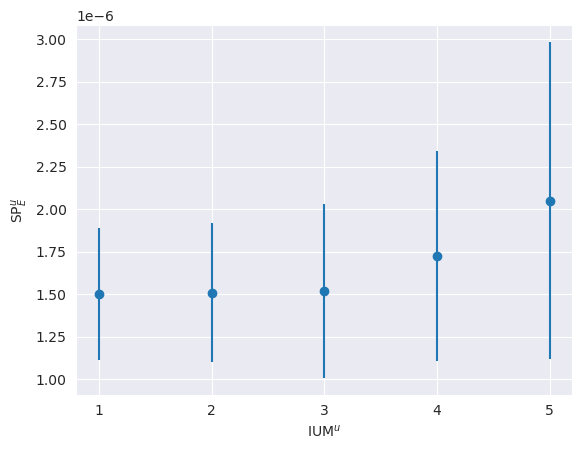

In [115]:
prob_derivatives_sampled_mean, prob_derivatives_sampled_std = bootstrapping(entropy_derivatives, 'active_eng_3', range(1, 6, 1), 'entropy_derivative', sample_size=100, num_samples=1000)
plot_bootstrapping(prob_derivatives_sampled_mean, prob_derivatives_sampled_std, f'entropy_derivative_n_clusters{n_clusters}.png', 'IUM$^u$', 'SP$_E^u$', [1, 2, 3, 4, 5])

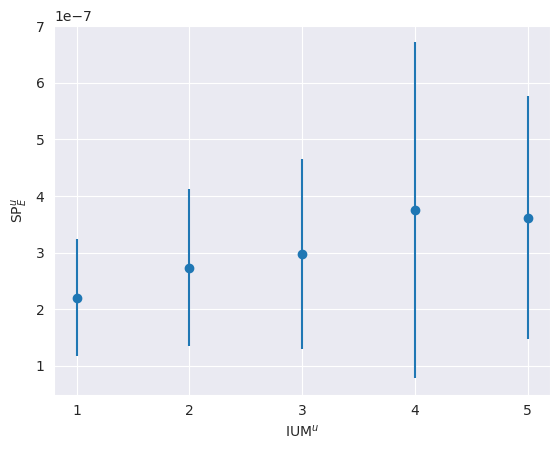

In [118]:
prob_derivatives_sampled_mean, prob_derivatives_sampled_std = bootstrapping(rao_stirling_derivatives, 'active_eng_3', range(1, 6, 1), 'rao_stirling_derivative', sample_size=100, num_samples=1000)
plot_bootstrapping(prob_derivatives_sampled_mean, prob_derivatives_sampled_std, f'rao_stirling_derivative_n_clusters{n_clusters}.png', 'IUM$^u$', 'SP$_E^u$', [1, 2, 3, 4, 5])

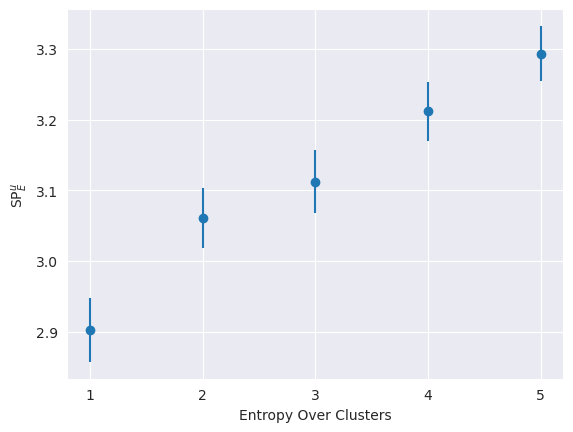

In [99]:
prob_derivatives_sampled_mean, prob_derivatives_sampled_std = bootstrapping(users_active_eng, 'active_eng_3', range(1, 6, 1), 'entropy_over_clusters', sample_size=100, num_samples=1000)
plot_bootstrapping(prob_derivatives_sampled_mean, prob_derivatives_sampled_std, f'entropy.png', 'Entropy Over Clusters', 'SP$_E^u$', [1, 2, 3, 4, 5])

# 2d visualization
Check that the distribution of the components of tracks gets closer to the center as the rank of the listened track gets higher

In [100]:
svd_embeddings = svd_embeddings.merge(distances_index_song_id, on='song_id')

In [101]:
pca = PCA()

In [102]:
pca_components = pca.fit_transform(svd_embeddings_matrix)

In [103]:
centroids_pca = pca.transform(clusterer.cluster_centers_)

In [104]:
first_components = []
second_components = []
third_components = []
columns_names = [f'pca_{i}_component' for i in range(3)]

for row in tqdm(svd_embeddings.iterrows()):
    row = row[1]
    track_distances_index = row.distances_index
    label_index = row.labels
    pca_track_vector = pca_components[track_distances_index][:3]
    pca_label_vector = centroids_pca[label_index][:3]
    
    difference = pca_track_vector - pca_label_vector

    first_components += [difference[0]]
    second_components += [difference[1]]
    third_components += [difference[2]]
    
for i, vec in enumerate([first_components, second_components, third_components]):
    svd_embeddings[f'pca_{i}_component'] = vec

72555it [00:01, 43345.57it/s]


In [105]:
first_two_components_users_one_week = users_one_week.merge(svd_embeddings[['song_id'] + columns_names], on='song_id')

/tmp/ipykernel_25633/1199862783.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[legend_title] = df['track_rank_in_cluster']
/home/marta/miniconda3/envs/curiosity/lib/python3.11/site-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


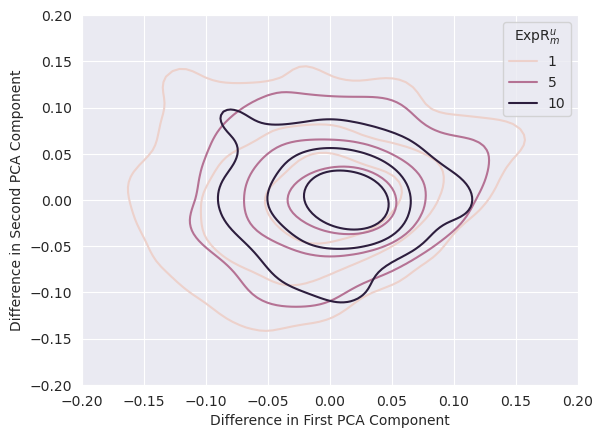

In [106]:
i = 0
j = 1
# df = first_two_components_users_one_week[((first_two_components_users_one_week.track_rank_in_cluster == 1) | (first_two_components_users_one_week.track_rank_in_cluster == 10))]
l, m, n = 1, 5, 10
df = first_two_components_users_one_week[((first_two_components_users_one_week.track_rank_in_cluster == l) | (first_two_components_users_one_week.track_rank_in_cluster == m) | (first_two_components_users_one_week.track_rank_in_cluster == n))]
# which_rank = 5
# df = first_two_components_users_one_week[first_two_components_users_one_week.track_rank_in_cluster == which_rank]

legend_title = 'ExpR$^u_m$'
df[legend_title] = df['track_rank_in_cluster']
ax = sns.kdeplot(data=df, x=f'pca_{i}_component', y=f'pca_{j}_component', hue=legend_title, fill=False, cmap="Blues", common_norm=False, levels=np.linspace(0, 1., 5))
# sns.kdeplot(data=df, x="difference_first", hue='track_rank_in_cluster', fill=False, common_norm=False)
plt.xlim((-0.2, 0.2))
plt.ylim((-0.2, 0.2))

plt.xlabel("Difference in First PCA Component")
plt.ylabel("Difference in Second PCA Component")
plt.savefig(f'pca_distance_from_centroids_n_clusters{n_clusters}.png', dpi=300)

In [107]:
users_one_week_active_eng = users_one_week.merge(ils_questions, left_on='user_id', right_on='uid', how='inner')

# Let's apply a multilevel linear regression model

In [108]:
# Ordinary Least Squares linear model with rank and active engagement
# Restrict to the first 10 listened tracks
# Try to predict the percentage distance from cluster centroid
# The independent variables are
## Rank in cluster: the more you listen, the closer you get to the center
## Active engagement
limit = 10
dependent_variable = 'percentage_distance'
users_one_week_active_eng_10 = users_one_week_active_eng[users_one_week_active_eng.track_rank_in_cluster < limit]

linear_model_distance = smf.ols(f"{dependent_variable} ~ track_rank_in_cluster + active_eng_3",
                    users_one_week_active_eng_10,
                    #groups= "active_eng_3"
                    ).fit()

print(linear_model_distance.summary2())

                   Results: Ordinary least squares
Model:              OLS                 Adj. R-squared:     0.022     
Dependent Variable: percentage_distance AIC:                49239.1521
Date:               2025-02-03 16:31    BIC:                49265.3373
No. Observations:   45633               Log-Likelihood:     -24617.   
Df Model:           2                   F-statistic:        508.4     
Df Residuals:       45630               Prob (F-statistic): 4.37e-219 
R-squared:          0.022               Scale:              0.17223   
----------------------------------------------------------------------
                       Coef.  Std.Err.    t     P>|t|   [0.025  0.975]
----------------------------------------------------------------------
Intercept              0.1077   0.0069  15.6196 0.0000  0.0942  0.1212
track_rank_in_cluster -0.0363   0.0011 -31.7470 0.0000 -0.0385 -0.0340
active_eng_3           0.0070   0.0019   3.5846 0.0003  0.0032  0.0108
--------------------------

In [109]:
# Ordinary Least Squares linear model with rank and active engagement
# Restrict to the first 10 listened tracks
# Try to predict the percentage popularity from cluster centroid
# The independent variables are
## Rank in cluster: the more you listen, the more popular stuff you listen to
## Active engagementlimit = 10
dependent_variable = 'percentage_popularity'
users_one_week_active_eng_10 = users_one_week_active_eng[users_one_week_active_eng.track_rank_in_cluster < limit]

linear_model_popularity = smf.ols(f"{dependent_variable} ~ track_rank_in_cluster + active_eng_3",
                    users_one_week_active_eng_10,
                    #groups= "active_eng_3"
                    ).fit()

print(linear_model_popularity.summary2())

                    Results: Ordinary least squares
Model:              OLS                   Adj. R-squared:     0.010    
Dependent Variable: percentage_popularity AIC:                8557.5683
Date:               2025-02-03 16:31      BIC:                8583.7535
No. Observations:   45633                 Log-Likelihood:     -4275.8  
Df Model:           2                     F-statistic:        227.9    
Df Residuals:       45630                 Prob (F-statistic): 3.20e-99 
R-squared:          0.010                 Scale:              0.070622 
-----------------------------------------------------------------------
                        Coef.  Std.Err.    t     P>|t|   [0.025  0.975]
-----------------------------------------------------------------------
Intercept               0.3065   0.0044  69.4303 0.0000  0.2978  0.3151
track_rank_in_cluster  -0.0143   0.0007 -19.4957 0.0000 -0.0157 -0.0128
active_eng_3           -0.0104   0.0012  -8.3298 0.0000 -0.0128 -0.0079
------------

Export mean distance for editorial playlist analysis

In [110]:
users_clusters_in_last_six_months[['song_id', 'percentage_distance', 'labels']].groupby(['song_id']).first().to_csv(f'{data_folder}/tracks_percentage_distance.csv')

In [111]:
editorial_playlists = pd.read_csv(f'{data_folder}/editorial_playlists.csv')

In [112]:
editorial_playlists.list_tracks = editorial_playlists.list_tracks.apply(ast.literal_eval)

In [113]:
editorial_playlists['song_id'] = editorial_playlists.list_tracks.apply(lambda x: [anonymized_to_integers[song_id] for song_id in x])

In [114]:
editorial_playlists.to_csv(f'{data_folder}/editorial_playlists_integer_id.csv', index=False)

In [115]:
subset_users = ils_questions[ils_questions.uid.isin(long_term_les.user_id.unique())]

In [116]:
subset_users['age_at_listening'] = 2022 - subset_users['E_birth_year']
subset_users = subset_users[['uid', 'active_eng_3', 'E_gender', 'age_at_listening']]
subset_users = subset_users.drop_duplicates(subset='uid', keep='first')

/tmp/ipykernel_25633/3980516613.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_users['age_at_listening'] = 2022 - subset_users['E_birth_year']


In [117]:
subset_users.age_at_listening.mean(), subset_users.age_at_listening.std()

(35.782800982800985, 13.406237530922384)

In [118]:
subset_users.active_eng_3.mean(), subset_users.active_eng_3.std()

(3.173955773955774, 1.021378666291604)

In [119]:
subset_users[['E_gender', 'active_eng_3']].groupby('E_gender').value_counts().to_csv('subset_users.csv')

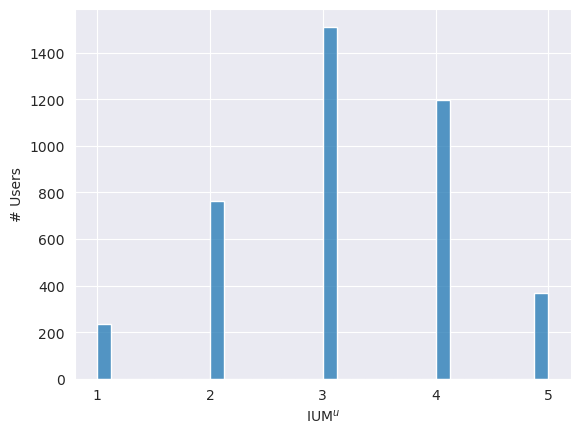

In [120]:
ax = sns.histplot(data=subset_users, x="active_eng_3")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

ax.set(xlabel='IUM$^u$', ylabel='# Users')
plt.savefig(f'replies.png', dpi=300)